# Proyecto ML - Detección automática de transacciones fraudulentas con tarjeta de crédito

**Integrantes:** Jacobo Blandón Castro - Johan Antonio Peña López
**Metodología:** CRISP-DM
**Dataset:** `credit-card-fraud.csv` - 5.000 transacciones, 22 variables.
**Objetivo:** clasificar cada transacción como fraudulenta (`Class = 1`) o legítima (`Class = 0`) a partir de variables conocidas en el momento de la autorización.

## Instalación de dependencias

In [1]:
%pip install ydata-profiling imbalanced-learn


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: /Users/blandev/Documents/seminario/machine-learning/trabajo-final/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.

## Importación de librerías

In [2]:
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, spearmanr, mannwhitneyu
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from ydata_profiling import ProfileReport

Ruta del dataset: `/content/credit-card-fraud.csv` en Colab y `../content/credit-card-fraud.csv` en local.

In [3]:
import os
from urllib.request import urlretrieve

URL_DATASET = 'https://raw.githubusercontent.com/blandevv/credit-card-fraud-detection/main/content/credit-card-fraud.csv'

DATA_PATH = '/content/credit-card-fraud.csv'

rutas = [DATA_PATH, '../content/credit-card-fraud.csv']

if not any(os.path.exists(r) for r in rutas):
    print('Dataset no encontrado; descargando desde el repositorio...')
    os.makedirs(os.path.dirname(DATA_PATH), exist_ok=True)
    urlretrieve(URL_DATASET, DATA_PATH)
    print('Descargado en', DATA_PATH)

RUTA_EXISTENTE = next(r for r in rutas if os.path.exists(r))
df = pd.read_csv(RUTA_EXISTENTE, encoding='utf-8')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

sns.set_theme(style='whitegrid')

Estructura, tipos y descripción estadística del dataset.

In [4]:
print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')

Dimensiones del dataset: 5000 filas x 22 columnas


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   RecordID          5000 non-null   object 
 1   V1                4662 non-null   float64
 2   V2                5000 non-null   float64
 3   V3                4705 non-null   float64
 4   V4                5000 non-null   float64
 5   V5                5000 non-null   float64
 6   V6                5000 non-null   float64
 7   V7                5000 non-null   float64
 8   V8                5000 non-null   float64
 9   V9                5000 non-null   float64
 10  V10               5000 non-null   float64
 11  Time              5000 non-null   int64  
 12  Amount            4647 non-null   float64
 13  Amount_log        5000 non-null   float64
 14  MerchantCategory  4642 non-null   object 
 15  DeviceType        5000 non-null   object 
 16  Class             5000 non-null   int64  


In [6]:
df.head()

,RecordID,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Time,Amount,Amount_log,MerchantCategory,DeviceType,Class,FullName,Phone,ZodiacSign,FavoriteColor,Hobby
0,REC00001,-1.321825,0.195964,-0.857088,0.747401,0.807869,-0.147251,2.860163,-0.274988,0.165504,0.443656,34441,37.70,3.6558,Restaurant,Mobile,0,Person_1,3.225919e+09,Scorpio,Gray,Gardening
1,REC00002,0.215179,1.834433,1.189629,0.727707,-0.614186,-0.927846,-0.139905,1.371764,0.467545,-0.776384,137005,14.99,2.7718,Gas,Mobile,0,Person_2,3.153457e+09,Scorpio,Purple,Sports
2,REC00003,-0.800550,-0.272141,0.171952,-0.648763,-1.882978,0.463394,0.212357,0.632169,-1.524188,-0.425202,79174,18.58,2.9743,Gas,Mobile,0,Person_3,3.041125e+09,Libra,White,Travel
3,REC00004,NaN,-0.742062,0.049136,-0.704023,-0.753476,1.180630,1.550394,-0.052800,0.112812,-0.181656,49674,14.06,2.7123,Grocery,Mobile,0,Person_4,3.031188e+09,Sagittarius,Pink,Travel
4,REC00005,0.531509,0.129864,NaN,0.733449,0.902569,0.771961,-1.938385,-0.668909,0.073830,-0.459917,90149,50.78,3.9471,Grocery,Mobile,0,Person_5,3.670206e+09,Cancer,Orange,Travel


In [7]:
df.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Time,Amount,Amount_log,Class,Phone
count,4662.000000,5000.000000,4705.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,4647.000000,5000.000000,5000.000000,5.000000e+03
mean,0.082171,0.082323,0.078014,0.057485,0.053014,-0.019689,0.003706,0.004762,-0.003342,0.048831,86625.120200,106.203536,3.443588,0.030000,3.505011e+09
std,1.106863,1.099680,1.081527,1.071890,1.106299,0.989054,0.995531,1.009373,0.999110,0.990224,49516.103152,1638.707665,1.140431,0.170604,2.869972e+08
min,-3.550170,-3.346702,-3.426226,-3.674606,-3.607571,-3.740608,-3.306223,-4.100293,-3.602710,-3.768876,8.000000,-100.000000,0.405500,0.000000,3.000422e+09
25%,-0.652398,-0.646241,-0.632974,-0.650526,-0.673056,-0.703338,-0.674131,-0.668939,-0.682031,-0.612356,44496.250000,14.675000,2.748750,0.000000,3.256522e+09
50%,0.050443,0.033104,0.051871,0.021911,0.019568,-0.022246,-0.004743,0.004248,0.018133,0.024384,86511.000000,34.800000,3.571950,0.000000,3.508745e+09
75%,0.738119,0.755244,0.739170,0.708478,0.691539,0.665357,0.702064,0.682048,0.676115,0.727149,128841.000000,71.425000,4.279975,0.000000,3.752571e+09
max,5.798961,5.178392,5.864380,4.908039,5.462631,3.634847,3.221892,3.784770,3.404966,3.663551,172740.000000,50000.000000,6.871800,1.000000,3.999907e+09


`RecordID`, `FullName` y `Phone` identifican personas, no transacciones: se eliminan.

In [8]:
columns_to_drop = [
    'RecordID',
    'FullName',
    'Phone'
]

df = df.drop(columns=columns_to_drop)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   V1                4662 non-null   float64
 1   V2                5000 non-null   float64
 2   V3                4705 non-null   float64
 3   V4                5000 non-null   float64
 4   V5                5000 non-null   float64
 5   V6                5000 non-null   float64
 6   V7                5000 non-null   float64
 7   V8                5000 non-null   float64
 8   V9                5000 non-null   float64
 9   V10               5000 non-null   float64
 10  Time              5000 non-null   int64  
 11  Amount            4647 non-null   float64
 12  Amount_log        5000 non-null   float64
 13  MerchantCategory  4642 non-null   object 
 14  DeviceType        5000 non-null   object 
 15  Class             5000 non-null   int64  
 16  ZodiacSign        5000 non-null   object 


Las columnas `object` se pasan a `category` para ahorrar memoria.

In [10]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   V1                4662 non-null   float64 
 1   V2                5000 non-null   float64 
 2   V3                4705 non-null   float64 
 3   V4                5000 non-null   float64 
 4   V5                5000 non-null   float64 
 5   V6                5000 non-null   float64 
 6   V7                5000 non-null   float64 
 7   V8                5000 non-null   float64 
 8   V9                5000 non-null   float64 
 9   V10               5000 non-null   float64 
 10  Time              5000 non-null   int64   
 11  Amount            4647 non-null   float64 
 12  Amount_log        5000 non-null   float64 
 13  MerchantCategory  4642 non-null   category
 14  DeviceType        5000 non-null   category
 15  Class             5000 non-null   int64   
 16  ZodiacSign        5000 n

Perfilado automático con `ydata-profiling`.

In [12]:
profile = ProfileReport(df, title='Reporte de perfilado - Transacciones con Tarjeta', minimal=True,
    progress_bar=False)
profile.to_file('reporte-perfilado.html')

  0%|          | 0/19 [00:00<?, ?it/s]

100%|██████████| 19/19 [00:00<00:00, 706.98it/s]

## Diagnóstico de valores nulos y duplicados

In [13]:
nulos = df.isna().sum()
print('Columnas con valores nulos:')
print(nulos[nulos > 0])

Columnas con valores nulos:
V1                  338
V3                  295
Amount              353
MerchantCategory    358
dtype: int64


In [14]:
print(f'\nFilas duplicadas: {df.duplicated().sum()}')
print(f'Filas totales: {len(df)}')


Filas duplicadas: 0
Filas totales: 5000


Sin filas duplicadas. Los nulos se concentran en cuatro columnas (5.9%–7.2%), lo que apunta a una pérdida aleatoria.

`Class` es la variable dependiente. Su distribución define la métrica y la estrategia de balanceo.

In [15]:
print('Distribución de la variable objetivo')
print(df['Class'].value_counts())
print(f'\nProporción de fraude: {df["Class"].mean():.4f}')

Distribución de la variable objetivo
Class
0    4850
1     150
Name: count, dtype: int64

Proporción de fraude: 0.0300


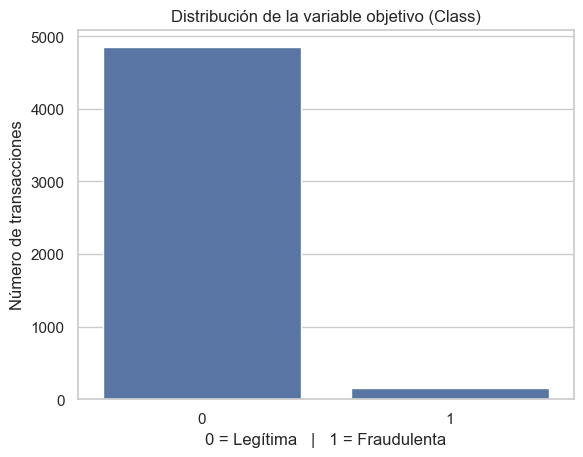

In [16]:
sns.countplot(x='Class', data=df)
plt.title('Distribución de la variable objetivo (Class)')
plt.xlabel('0 = Legítima   |   1 = Fraudulenta')
plt.ylabel('Número de transacciones')
plt.show()

Prueba de independencia chi-cuadrado (α = 0.05) para medir el aporte de cada categórica.

H₀: la variable categórica y `Class` son independientes.

In [17]:
categorical_cols = df.select_dtypes(include=['category']).columns

resultados_chi2 = []

for col in categorical_cols:
    tabla = pd.crosstab(df[col], df['Class'])
    chi2, p, _, _ = chi2_contingency(tabla)
    resultados_chi2.append({'Variable': col, 'chi2': round(chi2, 3), 'p_valor': round(p, 4)})

chi2_df = pd.DataFrame(resultados_chi2).sort_values('p_valor')
chi2_df['Decision'] = chi2_df['p_valor'].apply(
    lambda p: 'Asociación significativa' if p < 0.05 else 'Sin asociación'
)

display(chi2_df)

,Variable,chi2,p_valor,Decision
2,ZodiacSign,15.355,0.1668,Sin asociación
3,FavoriteColor,10.965,0.2781,Sin asociación
0,MerchantCategory,4.908,0.4272,Sin asociación
4,Hobby,7.185,0.6179,Sin asociación
1,DeviceType,0.085,0.7704,Sin asociación


Ninguna categórica resulta significativa (p > 0.05). Se conserva `MerchantCategory` por criterio de negocio y se eliminan `ZodiacSign`, `FavoriteColor`, `Hobby` y `DeviceType` (96% en una sola categoría).

In [18]:
columns_to_drop = [
    'ZodiacSign',
    'FavoriteColor',
    'Hobby',
    'DeviceType'
]

df = df.drop(columns=columns_to_drop)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   V1                4662 non-null   float64 
 1   V2                5000 non-null   float64 
 2   V3                4705 non-null   float64 
 3   V4                5000 non-null   float64 
 4   V5                5000 non-null   float64 
 5   V6                5000 non-null   float64 
 6   V7                5000 non-null   float64 
 7   V8                5000 non-null   float64 
 8   V9                5000 non-null   float64 
 9   V10               5000 non-null   float64 
 10  Time              5000 non-null   int64   
 11  Amount            4647 non-null   float64 
 12  Amount_log        5000 non-null   float64 
 13  MerchantCategory  4642 non-null   category
 14  Class             5000 non-null   int64   
dtypes: category(1), float64(12), int64(2)
memory usage: 552.1 KB


`Amount_log = log(1 + Amount)`, así que sirve como regla de integridad: todo `Amount` que no se reconstruya con tolerancia 0.05 está corrupto.

In [20]:
df['Amount_reconstruido'] = np.expm1(df['Amount_log'])
df['es_incoherente'] = (df['Amount'] - df['Amount_reconstruido']).abs() > 0.05

In [21]:
incoherentes = df.loc[df['es_incoherente'], ['Amount', 'Amount_log', 'Amount_reconstruido', 'Class']]
display(incoherentes)

,Amount,Amount_log,Amount_reconstruido,Class
31,50000.0,4.4554,85.090580,0
1168,50000.0,3.4697,31.127103,0
1238,-100.0,3.1637,22.657969,0
1595,-100.0,3.5953,35.426626,0
2535,50000.0,2.5418,11.702515,0
2841,-100.0,3.5296,33.110321,0
3173,-100.0,2.6631,13.340676,0
3233,-100.0,1.7595,4.809532,0
3849,50000.0,2.1974,8.001579,0
4257,50000.0,4.3335,75.210557,0


In [22]:
print(f'\nRegistros incoherentes: {df["es_incoherente"].sum()}')
print(f'De los cuales con Class = 1: {df.loc[df["es_incoherente"], "Class"].sum()}')


Registros incoherentes: 10
De los cuales con Class = 1: 0


Diez registros están corruptos: cinco con `Amount = -100` y cinco con `Amount = 50000`. En todos, `Amount_log` devuelve un monto plausible, así que se corrigen desde ahí.

## Limpieza de valores nulos

Antes de imputar se prueba si la ausencia de datos depende de `Class`.

In [23]:
for col in ['V1', 'V3', 'MerchantCategory']:
    tabla = pd.crosstab(df[col].isna(), df['Class'])
    chi2, p, _, _ = chi2_contingency(tabla)
    print(f'{col:20s} P(fraude | nulo) = {df.loc[df[col].isna(), "Class"].mean():.4f} | '
          f'p-valor = {p:.4f}')

V1                   P(fraude | nulo) = 0.0237 | p-valor = 0.5881
V3                   P(fraude | nulo) = 0.0305 | p-valor = 1.0000
MerchantCategory     P(fraude | nulo) = 0.0363 | p-valor = 0.5714


p > 0.05 en los tres casos: el mecanismo de pérdida es aleatorio (MCAR) y la imputación por mediana es válida.

Los 353 nulos de `Amount` se recuperan de `Amount_log` con la transformación inversa, que es exacta.

In [24]:
df['Amount'] = np.where(df['es_incoherente'], df['Amount_reconstruido'], df['Amount'])
df['Amount'] = df['Amount'].fillna(df['Amount_reconstruido'])

In [25]:
df = df.drop(columns=['Amount_reconstruido', 'es_incoherente'])

In [26]:
print(f'Nulos restantes en Amount: {df["Amount"].isna().sum()}')
print('Reporte de nulos:')
print(df.isna().sum()[df.isna().sum() > 0])

Nulos restantes en Amount: 0
Reporte de nulos:
V1                  338
V3                  295
MerchantCategory    358
dtype: int64


`V1` y `V3` se imputan con la mediana y se añade una indicadora de valor faltante para cada una.

In [27]:
for col in ['V1', 'V3']:
    df[f'{col}_missing'] = df[col].isna().astype(int)
    df[col] = df[col].fillna(df[col].median())

In [28]:
df.isna().sum()[df.isna().sum() > 0]

MerchantCategory    358
dtype: int64

Los 358 nulos de `MerchantCategory` se imputan con `Other`, que ya existe como categoría y equivale a 'categoría no registrada'.

In [29]:
df['MerchantCategory'] = df['MerchantCategory'].fillna('Other')
df['MerchantCategory'] = df['MerchantCategory'].astype('category')

In [30]:
print(f'Nulos totales restantes: {df.isna().sum().sum()}')

Nulos totales restantes: 0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   V1                5000 non-null   float64 
 1   V2                5000 non-null   float64 
 2   V3                5000 non-null   float64 
 3   V4                5000 non-null   float64 
 4   V5                5000 non-null   float64 
 5   V6                5000 non-null   float64 
 6   V7                5000 non-null   float64 
 7   V8                5000 non-null   float64 
 8   V9                5000 non-null   float64 
 9   V10               5000 non-null   float64 
 10  Time              5000 non-null   int64   
 11  Amount            5000 non-null   float64 
 12  Amount_log        5000 non-null   float64 
 13  MerchantCategory  5000 non-null   category
 14  Class             5000 non-null   int64   
 15  V1_missing        5000 non-null   int64   
 16  V3_missing        5000 n

`Amount_log` es redundante una vez reconstruido `Amount`. Se conserva `Amount` por su significado de negocio y porque admite las reglas de calidad.

In [32]:
df = df.drop(columns=['Amount_log'])
df.info()
print('\nVariables resultantes para el entrenamiento:')
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   V1                5000 non-null   float64 
 1   V2                5000 non-null   float64 
 2   V3                5000 non-null   float64 
 3   V4                5000 non-null   float64 
 4   V5                5000 non-null   float64 
 5   V6                5000 non-null   float64 
 6   V7                5000 non-null   float64 
 7   V8                5000 non-null   float64 
 8   V9                5000 non-null   float64 
 9   V10               5000 non-null   float64 
 10  Time              5000 non-null   int64   
 11  Amount            5000 non-null   float64 
 12  MerchantCategory  5000 non-null   category
 13  Class             5000 non-null   int64   
 14  V1_missing        5000 non-null   int64   
 15  V3_missing        5000 non-null   int64   
dtypes: category(1), float64(

In [33]:
variables_eliminadas = {
    'Identificadores personales': ['RecordID', 'FullName', 'Phone'],
    'Sin relacion funcional con el fraude': ['ZodiacSign', 'FavoriteColor', 'Hobby'],
    'Baja cardinalidad (96% Mobile)': ['DeviceType'],
    'Redundante con Amount': ['Amount_log']
}

for motivo, cols in variables_eliminadas.items():
    print(f'{motivo}: {", ".join(cols)}')

print(f'\nVariables finales: {df.shape[1] - 1} predictores + 1 variable objetivo')

Identificadores personales: RecordID, FullName, Phone
Sin relacion funcional con el fraude: ZodiacSign, FavoriteColor, Hobby
Baja cardinalidad (96% Mobile): DeviceType
Redundante con Amount: Amount_log

Variables finales: 15 predictores + 1 variable objetivo


Matriz de correlación de Pearson entre las variables numéricas.

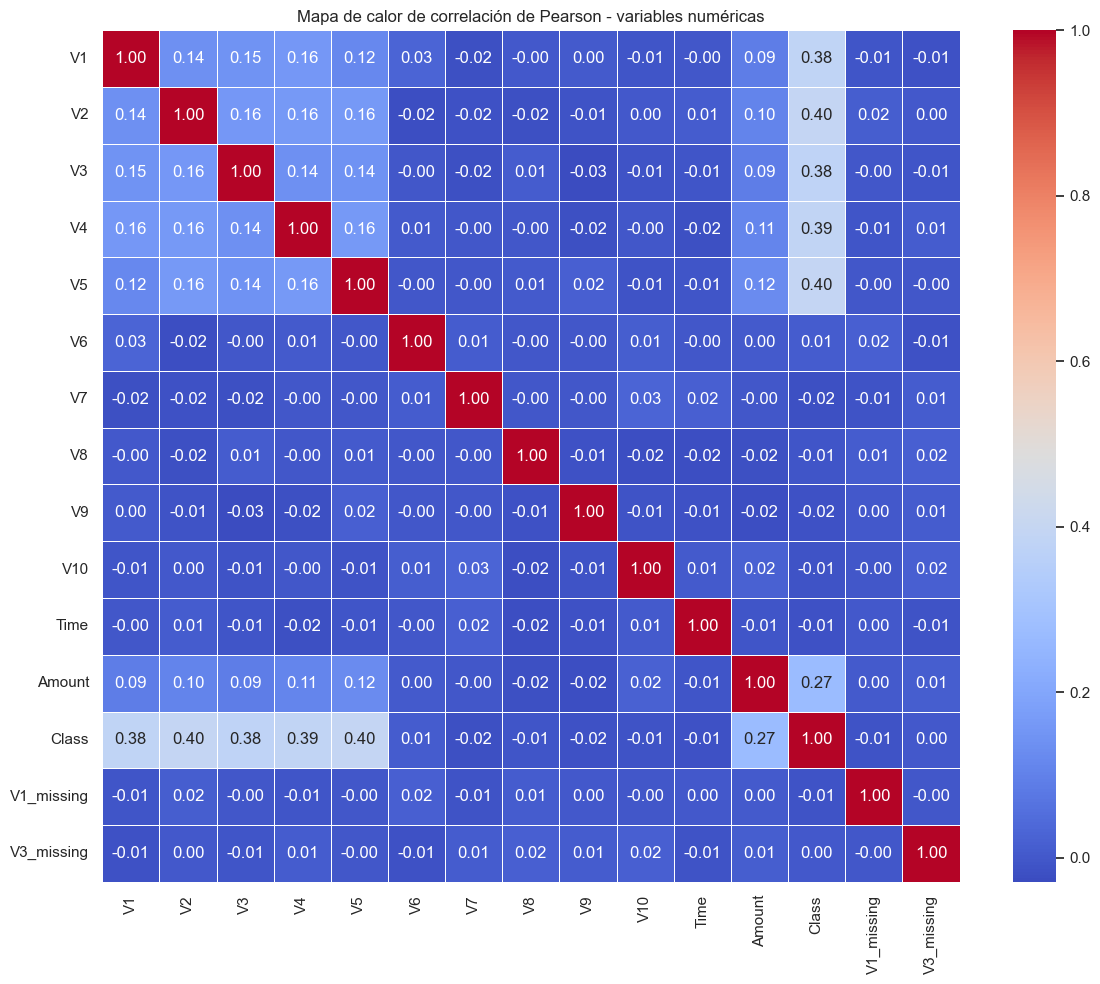

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Time,Amount,Class,V1_missing,V3_missing
V1,1.000000,0.139846,0.145672,0.156435,0.119007,0.029350,-0.020611,-0.000621,0.003758,-0.007390,-0.002199,0.089788,0.381361,-0.007453,-0.014594
V2,0.139846,1.000000,0.159081,0.163164,0.161134,-0.022183,-0.016796,-0.020788,-0.009748,0.000368,0.008122,0.104694,0.396906,0.015153,0.002848
V3,0.145672,0.159081,1.000000,0.138318,0.140810,-0.002184,-0.017625,0.009729,-0.028960,-0.008983,-0.008541,0.091073,0.377742,-0.001680,-0.005872
V4,0.156435,0.163164,0.138318,1.000000,0.162658,0.005776,-0.002390,-0.004562,-0.017302,-0.001448,-0.019634,0.108225,0.386464,-0.007782,0.007370
V5,0.119007,0.161134,0.140810,0.162658,1.000000,-0.002035,-0.002925,0.005035,0.018490,-0.010990,-0.006398,0.124998,0.395215,-0.002037,-0.003663
V6,0.029350,-0.022183,-0.002184,0.005776,-0.002035,1.000000,0.010458,-0.000927,-0.001045,0.011861,-0.002292,0.004054,0.008315,0.016717,-0.014376
V7,-0.020611,-0.016796,-0.017625,-0.002390,-0.002925,0.010458,1.000000,-0.001625,-0.001359,0.030622,0.015662,-0.004221,-0.020089,-0.009283,0.010587
V8,-0.000621,-0.020788,0.009729,-0.004562,0.005035,-0.000927,-0.001625,1.000000,-0.012984,-0.021856,-0.020998,-0.020731,-0.005050,0.008551,0.015486
V9,0.003758,-0.009748,-0.028960,-0.017302,0.018490,-0.001045,-0.001359,-0.012984,1.000000,-0.009197,-0.013894,-0.022307,-0.016516,0.001754,0.008104
V10,-0.007390,0.000368,-0.008983,-0.001448,-0.010990,0.011861,0.030622,-0.021856,-0.009197,1.000000,0.007050,0.022131,-0.012297,-0.001645,0.017316


In [34]:
correlation_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Mapa de calor de correlación de Pearson - variables numéricas')
plt.tight_layout()
plt.show()

display(correlation_matrix)

## Análisis de relaciones no lineales

In [35]:
numerical_cols = df.select_dtypes(include='number').columns.drop('Class')

In [36]:
comparacion = []
for col in numerical_cols:
    pearson = df[col].corr(df['Class'])
    spearman = df[col].corr(df['Class'], method='spearman')
    _, p_mwu = mannwhitneyu(
        df.loc[df['Class'] == 0, col].dropna(),
        df.loc[df['Class'] == 1, col].dropna()
    )
    comparacion.append({
        'Variable': col,
        'Pearson': round(pearson, 4),
        'Spearman': round(spearman, 4),
        'MWU_p': round(p_mwu, 4)
    })

In [37]:
display(pd.DataFrame(comparacion))

,Variable,Pearson,Spearman,MWU_p
0,V1,0.3814,0.2566,0.0000
1,V2,0.3969,0.2711,0.0000
2,V3,0.3777,0.2497,0.0000
3,V4,0.3865,0.2642,0.0000
4,V5,0.3952,0.2647,0.0000
5,V6,0.0083,0.0055,0.6979
6,V7,-0.0201,-0.0202,0.1528
7,V8,-0.0050,-0.0092,0.5132
8,V9,-0.0165,-0.0121,0.3910
9,V10,-0.0123,-0.0107,0.4508


`V1`–`V5` separan casi por completo las clases: IQR [-0.69, 0.69] en legítimas frente a [1.51, 3.36] en fraudulentas.

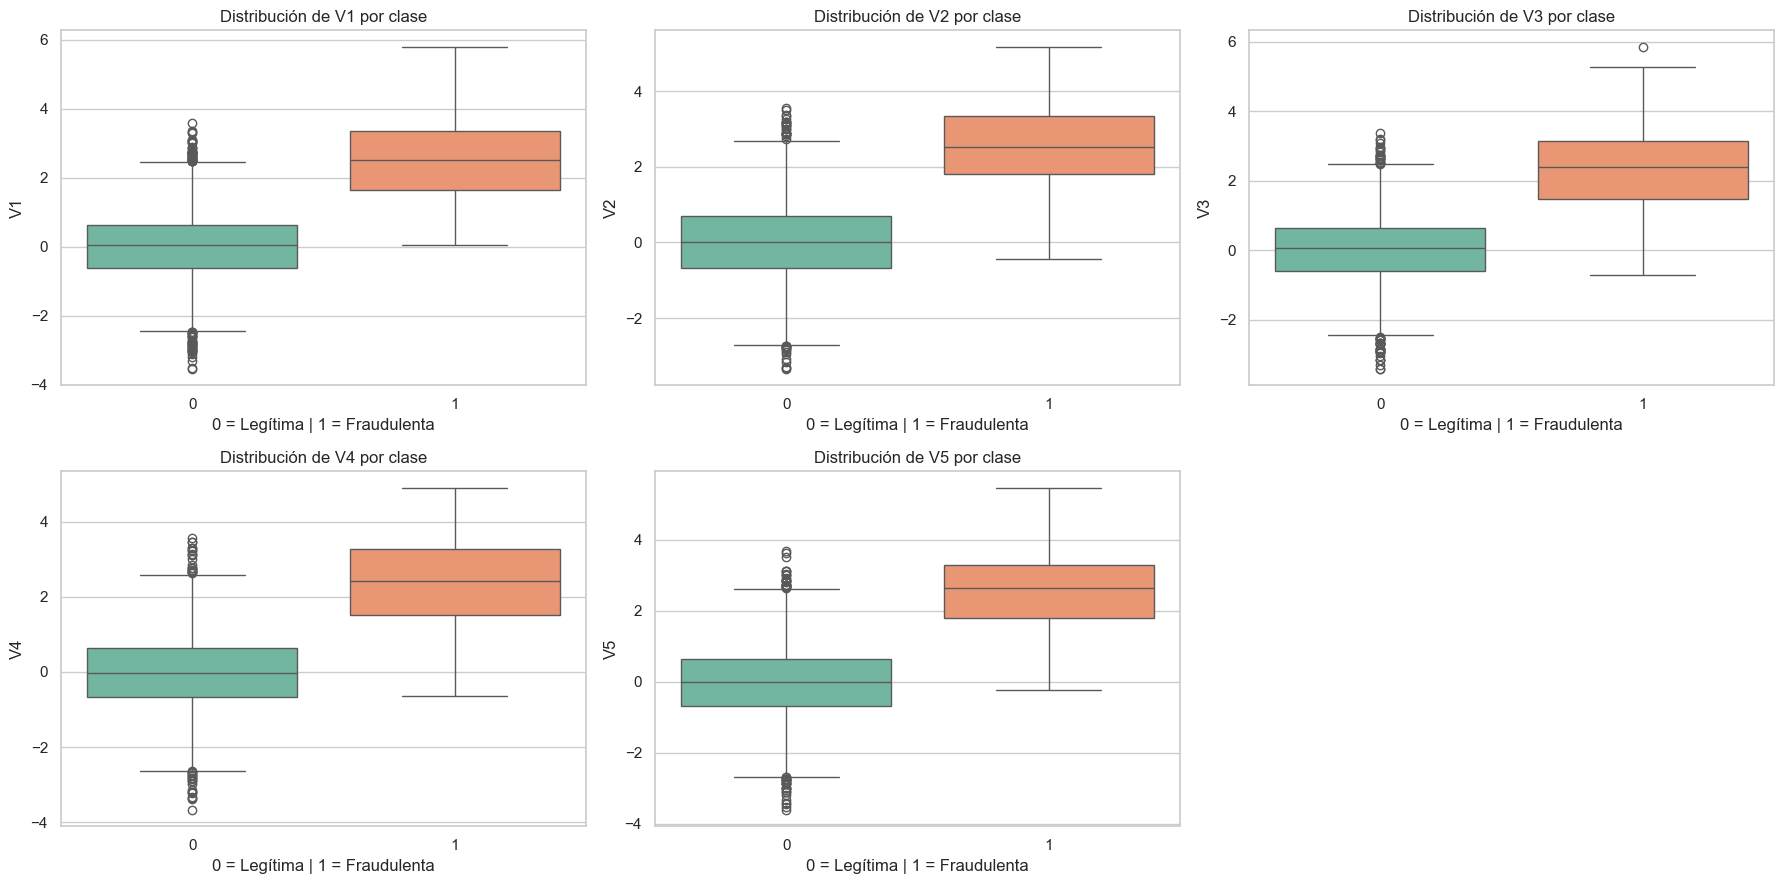

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for ax, col in zip(axes.flat, ['V1', 'V2', 'V3', 'V4', 'V5']):
    sns.boxplot(x='Class', y=col, data=df, ax=ax, palette='Set2')
    ax.set_title(f'Distribución de {col} por clase')
    ax.set_xlabel('0 = Legítima | 1 = Fraudulenta')

axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

Atípicos por criterio IQR en las variables numéricas. `P(fraude | atipico)` es la probabilidad de fraude cuando la variable es atípica.

In [39]:
variables_a_analizar = [col for col in numerical_cols if df[col].nunique() > 2]

filas = []

for col in variables_a_analizar:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    atipico = (df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)
    filas.append({
        'Variable': col,
        'n_atipicos': int(atipico.sum()),
        'P(fraude | atipico)': round(df.loc[atipico, 'Class'].mean(), 4) if atipico.any() else 0.0,
        'P(fraude | normal)': round(df.loc[~atipico, 'Class'].mean(), 4)
    })

atipicos = pd.DataFrame(filas).sort_values('P(fraude | atipico)', ascending=False)
atipicos['Razon'] = (atipicos['P(fraude | atipico)'] / atipicos['P(fraude | normal)']).round(1)

display(atipicos)

amount_por_clase = df.groupby('Class')['Amount'].agg(['count', 'mean', 'median', 'max']).round(2)
amount_por_clase.index = ['Legitima (Class = 0)', 'Fraudulenta (Class = 1)']

print('Amount por clase')
display(amount_por_clase)


,Variable,n_atipicos,P(fraude | atipico),P(fraude | normal),Razon
3,V4,93,0.6559,0.0181,36.2
4,V5,107,0.6449,0.0166,38.8
1,V2,89,0.6404,0.0189,33.9
2,V3,113,0.5664,0.0176,32.2
0,V1,136,0.5368,0.0158,34.0
11,Amount,260,0.1885,0.0213,8.8
8,V9,31,0.0645,0.0298,2.2
9,V10,35,0.0286,0.0300,1.0
7,V8,44,0.0227,0.0301,0.8
5,V6,18,0.0000,0.0301,0.0


Amount por clase


,count,mean,median,max
Legitima (Class = 0),4850,49.63,33.70,386.55
Fraudulenta (Class = 1),150,141.14,98.56,963.66


In [40]:
v_senales = ['V1', 'V2', 'V3', 'V4', 'V5']
cualquiera = pd.Series(False, index=df.index)

for col in v_senales:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    cualquiera |= (df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)

print(f'Registros atipicos en al menos una de V1-V5: {cualquiera.sum()}')
print(f'De esos, fraudulentos: {df.loc[cualquiera, "Class"].sum()}')
print(f'Total de fraudulentos en el dataset: {df["Class"].sum()}')
print(f'P(fraude | atipico en V1-V5) = {df.loc[cualquiera, "Class"].mean():.4f}')

Registros atipicos en al menos una de V1-V5: 347
De esos, fraudulentos: 141
Total de fraudulentos en el dataset: 150
P(fraude | atipico en V1-V5) = 0.4063


Los atípicos de `V1`–`V5` concentran la señal: 141 de los 150 casos de fraude (94%) son atípicos en al menos una de las cinco y `P(fraude | atípico) = 0.4063` frente a 0.03 del dataset. Solo entre 5 y 10 de los 150 fraudes caen dentro del IQR de la clase legítima.

No se eliminan: aplicar el criterio IQR de forma automática sobre todas las numéricas habría borrado el 94% de la clase positiva. La limpieza se limitó a los registros que violan reglas de negocio.

En `V6`–`V10` los atípicos no se asocian al fraude (P = 0.00) y en `Amount` la señal también está en la cola derecha (P = 0.1885 frente a 0.0213).

1. **Señal fuerte:** `V1`–`V5`, con Pearson 0.38–0.40, p < 0.0001 e IQR prácticamente disjuntos.
2. **Señal débil:** `Amount`, con Pearson 0.2710 frente a Spearman 0.1301 y mediana de 33.70 USD en legítimas frente a 98.56 USD en fraudulentas. Su poder está en la cola derecha.
3. **Sin señal:** `V6`–`V10`, `Time` y las indicadoras de valor faltante.
4. **Multicolinealidad moderada** entre `V1`–`V5` (0.12–0.16).
5. **Los atípicos de `V1`–`V5` son la señal**, no ruido: se conservan.
6. **Balance 32:1:** la *accuracy* no sirve como métrica; se usarán PR-AUC, *recall* y matriz de confusión.

Cierra la preparación de datos: a partir de aquí solo se derivan variables, se codifican las categóricas y se separa en entrenamiento y prueba.

La multicolinealidad entre `V1` y `V5` es moderada (0.12–0.16), así que se aplica PCA sobre las diez componentes. Como `V1`–`V10` ya son componentes de un PCA previo, un segundo PCA solo rota esa rotación: se usa como diagnóstico.

In [41]:
componentes = [f'V{i}' for i in range(1, 11)]

X_componentes = StandardScaler().fit_transform(df[componentes])
pca = PCA()
Z = pca.fit_transform(X_componentes)

varianza = pd.DataFrame({
    'Componente': [f'PC{i}' for i in range(1, 11)],
    'Varianza explicada (%)': np.round(pca.explained_variance_ratio_ * 100, 2),
    'Varianza acumulada (%)': np.round(np.cumsum(pca.explained_variance_ratio_) * 100, 2)
})

display(varianza)

,Componente,Varianza explicada (%),Varianza acumulada (%)
0,PC1,15.97,15.97
1,PC2,10.44,26.41
2,PC3,10.18,36.60
3,PC4,10.07,46.67
4,PC5,9.92,56.59
5,PC6,9.60,66.20
6,PC7,8.77,74.96
7,PC8,8.61,83.57
8,PC9,8.27,91.84
9,PC10,8.16,100.00


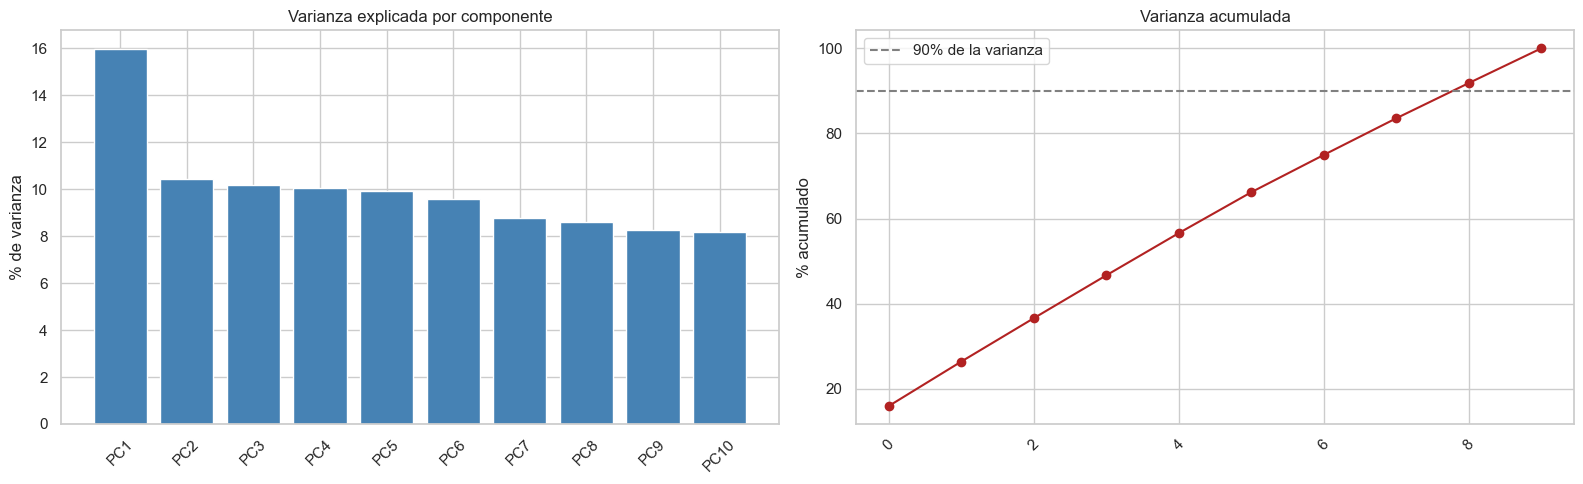

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].bar(varianza['Componente'], varianza['Varianza explicada (%)'], color='steelblue')
ax[0].set_title('Varianza explicada por componente')
ax[0].set_ylabel('% de varianza')
ax[0].tick_params(axis='x', rotation=45)

cum = varianza['Varianza acumulada (%)']
ax[1].plot(cum, marker='o', color='firebrick')
ax[1].axhline(90, linestyle='--', color='gray', label='90% de la varianza')
ax[1].set_title('Varianza acumulada')
ax[1].set_ylabel('% acumulado')
ax[1].tick_params(axis='x', rotation=45)
ax[1].legend()

plt.tight_layout()
plt.show()

In [43]:
print('Cargas (loadings) de los dos primeros componentes:')
display(pd.DataFrame(pca.components_[:2].T, index=componentes,
                     columns=['PC1', 'PC2']).round(3))

Cargas (loadings) de los dos primeros componentes:


,PC1,PC2
V1,0.426,0.028
V2,0.464,0.016
V3,0.441,-0.040
V4,0.461,0.074
V5,0.439,-0.004
V6,0.004,0.340
V7,-0.046,0.548
V8,-0.008,-0.362
V9,-0.025,-0.063
V10,-0.022,0.664


In [44]:
pd.DataFrame({
    'Componente': [f'PC{i}' for i in range(1, 11)],
    'Pearson con Class': [round(np.corrcoef(Z[:, i], df['Class'])[0, 1], 4) for i in range(10)],
    'p-valor MWU': [f'{mannwhitneyu(Z[df.Class == 0, i], Z[df.Class == 1, i]).pvalue:.2e}'
                    for i in range(10)]
})

,Componente,Pearson con Class,p-valor MWU
0,PC1,0.6858,8.52e-97
1,PC2,0.0153,2.19e-01
2,PC3,0.0007,9.10e-01
3,PC4,0.0084,6.47e-01
4,PC5,0.0153,1.47e-01
5,PC6,-0.0013,9.29e-01
6,PC7,0.0027,6.56e-01
7,PC8,0.0030,9.05e-01
8,PC9,-0.0079,4.20e-01
9,PC10,-0.0233,7.09e-02


`PC1` explica el 15.97% de la varianza y correlaciona 0.6858 con `Class`, muy por encima de cualquier variable individual; `PC2`–`PC5` no son significativos. Sus cargas (0.43–0.46 sobre `V1`–`V5` y casi cero sobre el resto) muestran que `PC1` es el promedio estandarizado de las cinco primeras componentes.

Se conservan `V1`–`V10` individuales: los modelos por árboles aprovechan mejor los umbrales de cada componente que un único `PC1`.

`Time` son segundos desde la primera transacción (8 a 172.740, unas 48 horas). Se derivan `Hora` (0–47) y `Franja` (cuatro bloques). No se conserva `Hora` individual: 48 niveles frente a 150 casos de fraude favorecen el sobreajuste.

In [45]:
df['Hora'] = (df['Time'] // 3600).astype(int)
df['Franja'] = pd.cut(
    df['Hora'],
    bins=[-1, 5, 11, 17, 23],
    labels=['Madrugada (00-05)', 'Mañana (06-11)', 'Tarde (12-17)', 'Noche (18-23)']
)

display(df['Franja'].value_counts().sort_index())

Franja
Madrugada (00-05)    628
Mañana (06-11)       593
Tarde (12-17)        624
Noche (18-23)        651
Name: count, dtype: int64

In [46]:
tabla_franja = pd.crosstab(df['Franja'], df['Class'])
chi2, p, _, _ = chi2_contingency(tabla_franja)

display(tabla_franja)
display(tabla_franja.apply(lambda c: (c / c.sum()).round(4), axis=0))
print(f'Chi-cuadrado = {chi2:.3f} | p-valor = {p:.4f}')

Class,0,1
Franja,,
Madrugada (00-05),606,22
Mañana (06-11),579,14
Tarde (12-17),606,18
Noche (18-23),625,26


Class,0,1
Franja,,
Madrugada (00-05),0.2508,0.275
Mañana (06-11),0.2397,0.175
Tarde (12-17),0.2508,0.225
Noche (18-23),0.2587,0.325


Chi-cuadrado = 3.054 | p-valor = 0.3833


La proporción de fraude es plana en las cuatro franjas (2.3%–4.0%, p = 0.3833). Se conserva por si hubiera interacción con el monto y porque en producción sí existen patrones horarios; `Time` se mantiene porque los árboles capturan ventanas no monótonas.

`MerchantCategory` lleva one-hot con `drop='first'`, que evita la multicolinealidad perfecta en los modelos lineales y de distancia, y las numéricas se estandarizan con `StandardScaler`, necesario para KNN y SVM. Todo va dentro de un `ColumnTransformer` ajustado solo con el conjunto de entrenamiento.

In [47]:
X = df.drop(columns='Class')
y = df['Class']

columnas_numericas = X.select_dtypes(include='number').columns.tolist()
columnas_categoricas = X.select_dtypes(include='category').columns.tolist()

print('Variables numericas:')
print(columnas_numericas)
print(f'\nVariables categoricas: {columnas_categoricas}')
print(f'\nDimensiones de X: {X.shape}')

Variables numericas:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'Time', 'Amount', 'V1_missing', 'V3_missing', 'Hora']

Variables categoricas: ['MerchantCategory', 'Franja']

Dimensiones de X: (5000, 17)


70% entrenamiento y 30% prueba con muestreo estratificado, para conservar la proporción de fraude. El balanceo se aplica después de dividir y solo sobre entrenamiento.

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

print(f'Entrenamiento: {X_train.shape[0]} filas | fraude: {y_train.sum()} ({y_train.mean():.4f})')
print(f'Prueba:        {X_test.shape[0]} filas | fraude: {y_test.sum()} ({y_test.mean():.4f})')

Entrenamiento: 3500 filas | fraude: 105 (0.0300)
Prueba:        1500 filas | fraude: 45 (0.0300)


In [49]:
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
         columnas_categoricas)
    ]
)

X_train_t = preprocesador.fit_transform(X_train)
X_test_t = preprocesador.transform(X_test)

print(f'X_train transformado: {X_train_t.shape}')
print(f'X_test transformado:  {X_test_t.shape}')

X_train transformado: (3500, 24)
X_test transformado:  (1500, 24)


Con 3% de fraude (razón 32:1) un modelo puede tener 97% de *accuracy* sin detectar un solo fraude. Se comparan submuestreo aleatorio, SMOTE y `class_weight='balanced'`.

In [50]:
undersampler = RandomUnderSampler(random_state=42)
smote = SMOTE(random_state=42)

X_train_sub, y_train_sub = undersampler.fit_resample(X_train_t, y_train)
X_train_smo, y_train_smo = smote.fit_resample(X_train_t, y_train)

comparacion_balanceo = pd.DataFrame({
    'Estrategia': ['Original (sin balancear)', 'Submuestreo', 'SMOTE'],
    'Registros': [len(y_train), len(y_train_sub), len(y_train_smo)],
    'No fraudulentos': [(y_train == 0).sum(), (y_train_sub == 0).sum(), (y_train_smo == 0).sum()],
    'Fraudulentos': [y_train.sum(), y_train_sub.sum(), y_train_smo.sum()],
    'Proporcion de fraude': [round(y_train.mean(), 4), round(y_train_sub.mean(), 4),
                             round(y_train_smo.mean(), 4)]
})

display(comparacion_balanceo)

sinteticos_smote = int((y_train_smo == 1).sum() - y_train.sum())

print(f'Registros generados por SMOTE: {sinteticos_smote}')
print(f'Total de registros tras SMOTE: {len(y_train_smo)}')
print(f'Legitimas conservadas:         {(y_train_smo == 0).sum()}')


,Estrategia,Registros,No fraudulentos,Fraudulentos,Proporcion de fraude
0,Original (sin balancear),3500,3395,105,0.03
1,Submuestreo,210,105,105,0.50
2,SMOTE,6790,3395,3395,0.50


Registros generados por SMOTE: 3290
Total de registros tras SMOTE: 6790
Legitimas conservadas:         3395


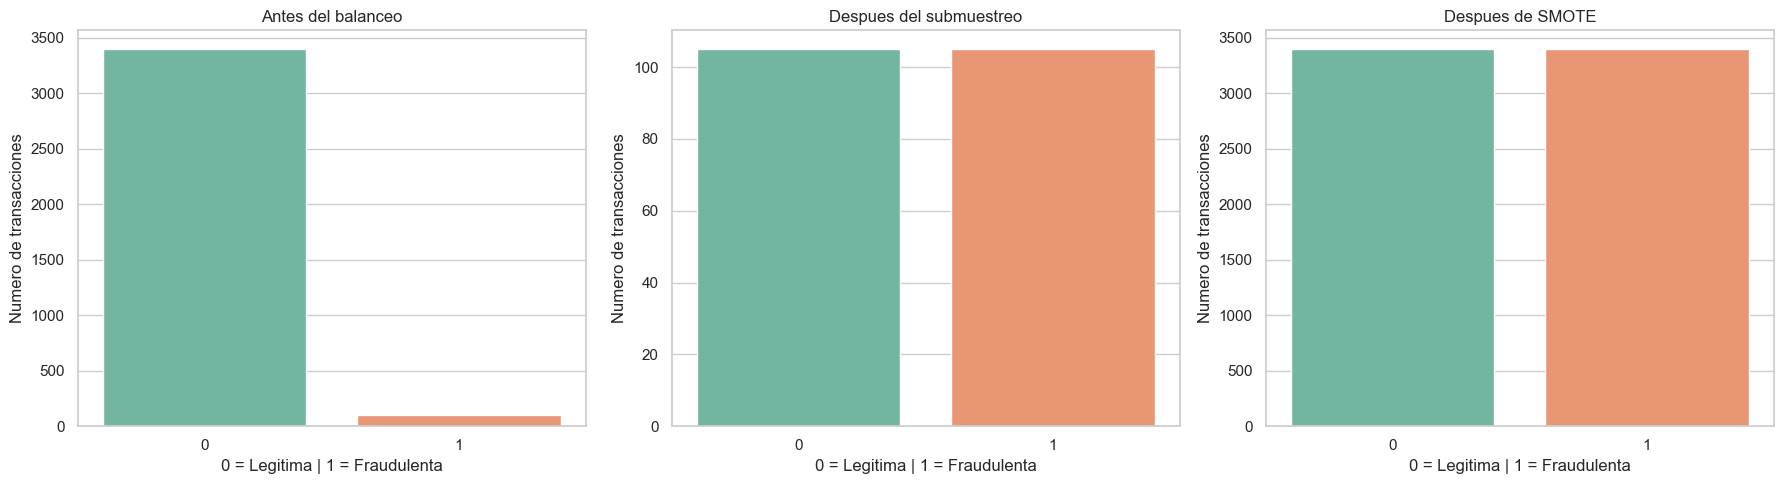

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (titulo, y_actual) in zip(axes, [
    ('Antes del balanceo', y_train),
    ('Despues del submuestreo', y_train_sub),
    ('Despues de SMOTE', y_train_smo)
]):
    sns.countplot(x=y_actual, ax=ax, palette='Set2', order=[0, 1])
    ax.set_title(titulo)
    ax.set_xlabel('0 = Legitima | 1 = Fraudulenta')
    ax.set_ylabel('Numero de transacciones')

plt.tight_layout()
plt.show()

El submuestreo deja 210 registros de entrenamiento (rápido, pero descarta 3.290 legítimas), SMOTE conserva las 3.395 y genera 3.290 fraudulentos sintéticos, y `class_weight='balanced'` no altera los datos. Se prueban las tres; el conjunto de prueba queda sin balancear, con la proporción real del 3%.

Etapa de modelamiento: los datos ya están preparados y se entrenan los ocho modelos del diseño de solución.

Ocho modelos: cinco clásicos (regresión logística, KNN, SVM, árbol de decisión y Naive Bayes) y tres ensambles (votación suave, *random forest* y *gradient boosting*).

La métrica principal es el PR-AUC (`average_precision`), porque con 3% de fraude la *accuracy* no discrimina. Se reportan además *recall*, *precision*, *F1* y la matriz de confusión.

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay,
                             roc_auc_score, average_precision_score, precision_recall_curve)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_clasicos = {
    'Regresion Logistica': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability=True),
    'Arbol de Decision': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB()
}

modelos_ensamble = {
    'Votacion': None,
    'Random Forest (bagging)': RandomForestClassifier(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

In [53]:
def con_estrategia(modelo, estrategia):
    """Clona el modelo y aplica class_weight='balanced' cuando la estrategia lo requiera."""
    modelo = clone(modelo)
    if estrategia == 'class_weight' and 'class_weight' in modelo.get_params():
        modelo.set_params(class_weight='balanced')
    return modelo

datos_entrenamiento = {
    'class_weight': (X_train_t, y_train),
    'Submuestreo': (X_train_sub, y_train_sub),
    'SMOTE':       (X_train_smo, y_train_smo),
}

todos_modelos = {**modelos_clasicos, **modelos_ensamble}
todos_modelos.pop('Votacion')

filas = []
for estrategia, (X, y) in datos_entrenamiento.items():
    for nombre, modelo in todos_modelos.items():
        m = con_estrategia(modelo, estrategia)
        puntajes = cross_val_score(m, X, y, cv=cv, scoring='average_precision', n_jobs=-1)
        filas.append({
            'Estrategia': estrategia,
            'Modelo': nombre,
            'PR-AUC (media)': round(float(puntajes.mean()), 4),
            'PR-AUC (std)': round(float(puntajes.std()), 4)
        })

comparacion_balanceo_cv = pd.DataFrame(filas)
pivot_cv = comparacion_balanceo_cv.pivot(index='Modelo', columns='Estrategia', values='PR-AUC (media)')

display(pivot_cv.sort_values('SMOTE', ascending=False).round(4))

Estrategia,SMOTE,Submuestreo,class_weight
Modelo,,,
Gradient Boosting,1.0000,0.9247,0.9676
Random Forest (bagging),1.0000,0.9991,0.9868
Regresion Logistica,1.0000,0.9996,0.9894
SVM,1.0000,0.9996,0.9869
KNN,0.9988,0.9983,0.9492
Naive Bayes,0.9979,0.9996,0.9765
Arbol de Decision,0.9893,0.9052,0.6555


In [54]:
promedio_por_estrategia = comparacion_balanceo_cv.groupby('Estrategia')['PR-AUC (media)'].mean()
promedio_por_estrategia = promedio_por_estrategia.sort_values(ascending=False)

estrategia_seleccionada = promedio_por_estrategia.index[0]
print('Estrategia con mejor PR-AUC promedio:')
print(promedio_por_estrategia.round(4))

X_modelo = datos_entrenamiento[estrategia_seleccionada][0]
y_modelo = datos_entrenamiento[estrategia_seleccionada][1]

print(f'\nEntrenamiento con la estrategia {estrategia_seleccionada}:')
print(f'Registros: {X_modelo.shape[0]} | Fraude: {y_modelo.sum()} ({y_modelo.mean():.4f})')

Estrategia con mejor PR-AUC promedio:
Estrategia
SMOTE           0.9980
Submuestreo     0.9752
class_weight    0.9303
Name: PR-AUC (media), dtype: float64

Entrenamiento con la estrategia SMOTE:
Registros: 6790 | Fraude: 3395 (0.5000)


`GridSearchCV` con `StratifiedKFold` de 5 pliegues y PR-AUC, sobre el set de entrenamiento. El conjunto de prueba se reserva para la medida final de calidad.

In [55]:
param_grid_clasicos = {
    'Regresion Logistica': {'C': [0.01, 0.1, 1, 10]},
    'KNN': {
        'n_neighbors': [3, 5, 7, 11],
        'weights': ['uniform', 'distance']
    },
    'SVM': {'C': [0.5, 1.0, 5.0], 'gamma': ['scale', 'auto']},
    'Arbol de Decision': {
        'max_depth': [3, 5, 7, None],
        'min_samples_split': [2, 5, 10]
    },
    'Naive Bayes': {'var_smoothing': [1e-9, 1e-8, 1e-7]}
}

mejores_clasicos = {}
resumen_tuning = []

for nombre, grid in param_grid_clasicos.items():
    modelo = con_estrategia(modelos_clasicos[nombre], estrategia_seleccionada)
    busqueda = GridSearchCV(modelo, grid, cv=cv, scoring='average_precision', n_jobs=-1)
    busqueda.fit(X_modelo, y_modelo)
    mejores_clasicos[nombre] = busqueda.best_estimator_
    resumen_tuning.append({
        'Modelo': nombre,
        'Mejor PR-AUC (CV)': round(float(busqueda.best_score_), 4),
        'Hiperparámetros': str(busqueda.best_params_)
    })
    print(f'{nombre:20s} -> {busqueda.best_score_:.4f} | {busqueda.best_params_}')

resumen_tuning_clasicos = pd.DataFrame(resumen_tuning)
display(resumen_tuning_clasicos)

Regresion Logistica  -> 1.0000 | {'C': 1}


KNN                  -> 0.9991 | {'n_neighbors': 7, 'weights': 'distance'}


SVM                  -> 1.0000 | {'C': 0.5, 'gamma': 'scale'}


Arbol de Decision    -> 0.9899 | {'max_depth': None, 'min_samples_split': 10}
Naive Bayes          -> 0.9979 | {'var_smoothing': 1e-09}


,Modelo,Mejor PR-AUC (CV),Hiperparámetros
0,Regresion Logistica,1.0000,{'C': 1}
1,KNN,0.9991,"{'n_neighbors': 7, 'weights': 'distance'}"
2,SVM,1.0000,"{'C': 0.5, 'gamma': 'scale'}"
3,Arbol de Decision,0.9899,"{'max_depth': None, 'min_samples_split': 10}"
4,Naive Bayes,0.9979,{'var_smoothing': 1e-09}


In [56]:
param_grid_ensambles = {
    'Random Forest (bagging)': {
        'n_estimators': [200, 400],
        'max_depth': [None, 5, 10],
        'max_features': ['sqrt', 'log2']
    },
    'Gradient Boosting': {
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [100, 200],
        'max_depth': [2, 3]
    }
}

mejores_ensambles = {}
resumen_tuning = []

for nombre, grid in param_grid_ensambles.items():
    modelo = con_estrategia(modelos_ensamble[nombre], estrategia_seleccionada)
    busqueda = GridSearchCV(modelo, grid, cv=cv, scoring='average_precision', n_jobs=-1)
    busqueda.fit(X_modelo, y_modelo)
    mejores_ensambles[nombre] = busqueda.best_estimator_
    resumen_tuning.append({
        'Modelo': nombre,
        'Mejor PR-AUC (CV)': round(float(busqueda.best_score_), 4),
        'Hiperparámetros': str(busqueda.best_params_)
    })
    print(f'{nombre:24s} -> {busqueda.best_score_:.4f} | {busqueda.best_params_}')

resumen_tuning_ensambles = pd.DataFrame(resumen_tuning)
display(resumen_tuning_ensambles)

Random Forest (bagging)  -> 1.0000 | {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 400}


Gradient Boosting        -> 1.0000 | {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


,Modelo,Mejor PR-AUC (CV),Hiperparámetros
0,Random Forest (bagging),1.0,"{'max_depth': None, 'max_features': 'sqrt', 'n..."
1,Gradient Boosting,1.0,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."


In [57]:
votacion = VotingClassifier(
    estimators=[('lr', mejores_clasicos['Regresion Logistica']),
                ('knn', mejores_clasicos['KNN']),
                ('svm', mejores_clasicos['SVM']),
                ('dt', mejores_clasicos['Arbol de Decision']),
                ('nb', mejores_clasicos['Naive Bayes'])],
    voting='soft'
)
votacion.fit(X_modelo, y_modelo)
print('VotingClassifier (soft) ajustado sobre los 5 clásicos afinados')

VotingClassifier (soft) ajustado sobre los 5 clásicos afinados


Los ocho modelos afinados se evalúan sobre el conjunto de prueba, que queda sin balancear. El mejor se elige por PR-AUC.

In [58]:
mejores_modelos = {**mejores_clasicos, **mejores_ensambles, 'Votacion (soft)': votacion}

resumen_eval = []

for nombre, modelo in mejores_modelos.items():
    y_pred = modelo.predict(X_test_t)
    y_proba = modelo.predict_proba(X_test_t)[:, 1]
    resumen_eval.append({
        'Modelo': nombre,
        'Recall': round(float(recall_score(y_test, y_pred)), 4),
        'Precision': round(float(precision_score(y_test, y_pred)), 4),
        'F1': round(float(f1_score(y_test, y_pred)), 4),
        'PR-AUC': round(float(average_precision_score(y_test, y_proba)), 4),
        'ROC-AUC': round(float(roc_auc_score(y_test, y_proba)), 4)
    })

evaluacion_test = pd.DataFrame(resumen_eval).sort_values('PR-AUC', ascending=False).reset_index(drop=True)
display(evaluacion_test)

,Modelo,Recall,Precision,F1,PR-AUC,ROC-AUC
0,Regresion Logistica,1.0000,0.8654,0.9278,0.9981,0.9999
1,SVM,0.9778,0.9362,0.9565,0.9943,0.9998
2,Votacion (soft),0.9778,0.9167,0.9462,0.9923,0.9996
3,Random Forest (bagging),0.9778,0.9565,0.9670,0.9920,0.9997
4,Gradient Boosting,0.9778,0.8800,0.9263,0.9858,0.9990
5,Naive Bayes,0.9111,0.7593,0.8283,0.9287,0.9731
6,KNN,0.9778,0.7586,0.8544,0.8923,0.9873
7,Arbol de Decision,0.9111,0.7069,0.7961,0.7399,0.9627


Modelo ganador: Regresion Logistica
PR-AUC: 0.9981 | ROC-AUC: 0.9999


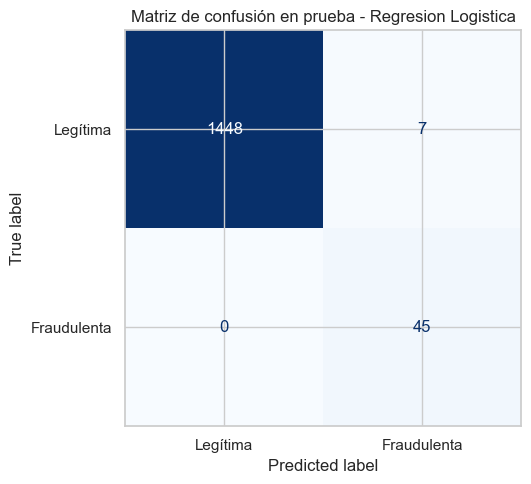

                 precision    recall  f1-score   support

   Legítima (0)       1.00      1.00      1.00      1455
Fraudulenta (1)       0.87      1.00      0.93        45

       accuracy                           1.00      1500
      macro avg       0.93      1.00      0.96      1500
   weighted avg       1.00      1.00      1.00      1500



In [59]:
mejor_fila = evaluacion_test.iloc[0]
mejor_nombre = mejor_fila['Modelo']
mejor_modelo = mejores_modelos[mejor_nombre]

y_pred_mejor = mejor_modelo.predict(X_test_t)
y_proba_mejor = mejor_modelo.predict_proba(X_test_t)[:, 1]

print(f'Modelo ganador: {mejor_nombre}')
print(f'PR-AUC: {mejor_fila["PR-AUC"]:.4f} | ROC-AUC: {mejor_fila["ROC-AUC"]:.4f}')

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mejor, ax=ax,
                                        display_labels=['Legítima', 'Fraudulenta'],
                                        cmap='Blues', colorbar=False)
ax.set_title(f'Matriz de confusión en prueba - {mejor_nombre}')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_mejor, target_names=['Legítima (0)', 'Fraudulenta (1)']))

In [60]:
print(f'Total de pruebas: {len(y_test)}')
print(f'Legítimas: {(y_test == 0).sum()} | Fraudulentas: {(y_test == 1).sum()}')

tp = confusion_matrix(y_test, y_pred_mejor)[1, 1]
fn = confusion_matrix(y_test, y_pred_mejor)[1, 0]
print(f'Fraudes detectados: {tp} de {tp + fn} fraudulentos')

Total de pruebas: 1500
Legítimas: 1455 | Fraudulentas: 45
Fraudes detectados: 45 de 45 fraudulentos


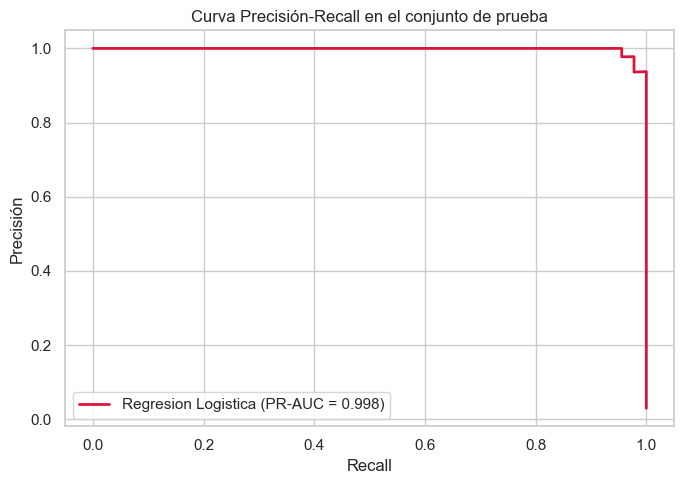

In [61]:
precision, recall, _ = precision_recall_curve(y_test, y_proba_mejor)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, lw=2, color='crimson',
        label=f'{mejor_nombre} (PR-AUC = {average_precision_score(y_test, y_proba_mejor):.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precisión')
ax.set_title('Curva Precisión-Recall en el conjunto de prueba')
ax.legend()
plt.tight_layout()
plt.show()

Gana la **regresión logística**: PR-AUC 0.9981, 45 de 45 frauds detectados (recall 100%) y 87% de precisión. Le siguen SVM (0.9943) y la votación suave (0.9923); *bagging* y *boosting* se quedan en 0.9920 y 0.9858.

Se elige por su equilibrio entre métricas y cero frauds escapados, y porque es el modelo más simple de explicar: sus coeficientes muestran qué variables empujan la decisión.

Se prioriza *recall* alto porque no dejar pasar fraude cuesta más que revisar una alerta legítima.